This notebook demonstrates a **wavelet-based approach to estimating eddy-covariance CO2 covariance** using the BE-Lon example dataset.

It focuses on the computational workflow rather than producing calibrated flux units, so the results are shown as covariance reconstructions rather than final flux values (unit converison needed).

Key steps covered here:
- read and preprocess BE-Lon `.ghg` data,
- compute the continuous wavelet transform with the Morlet wavelet,
- determine the sample support needed to avoid edge effects for a 30-minute window,
- apply the cross-wavelet transform to compute CO2 covariance,
- visualize the cross-scalogram for the selected interval.

The wavelet parameters are chosen to preserve covariance information across all available periods, using no padding and edge extension only where necessary.

For the theoretical background and application details, refer to the associated publication.

In [1]:
"""
Created on Thu May 14 2026

@author: Jonathan Bitton
"""
# Standard library imports
import os
import sys
import warnings
import zipfile

# Customize the warning format (exclude file paths and function names)
def custom_warning_format(message, category, filename, lineno, line=None):
    return f"{category.__name__}: {message}"
# Apply the custom warning format
warnings.formatwarning = custom_warning_format

# Get the directory of the current script
current_dir = os.path.dirname(os.path.abspath('Example_cov.ipynb'))

# Add the src folder to the Python path
sys.path.append(os.path.join(current_dir, "..", "src"))

# Third party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Local application/library specific imports
from cwtransform import Wavelet_Transform as WT

# Sampling interval
ts = 1/20

# Define the path to the data file
directory = os.path.join(current_dir, "..", "data","BE_Lon")

This step loads the BE_Lon measurement files and prepares the variables needed for the wavelet analysis.

The code reads compressed `.ghg` archives, extracts CO2 concentration and vertical wind speed, parses the timestamp fields, and builds a continuous time axis for the subsequent transform.

The dataset covers the July 28, 2024 observation period from 10:00 to 16:00, and the extracted data are aligned for the eddy-covariance computation.

In [2]:
#%% --- Extract data --- #
def get_xvar_data_from_ghg(directory=None, xvar=None):
    # Determine variable name based on xvar
    if str(xvar).lower()[0] == 'c':
        var_name = 'CO2 dry(umol/mol)'
        print('get_xvar_data : retrieving CO2 data')
    elif str(xvar).lower()[0] == 't':
        var_name = 'T (C)'
        print('get_xvar_data : retrieving temperature data')
    elif str(xvar).lower()[0] == 'h':
        var_name = 'H2O dry(mmol/mol)'
        print('get_xvar_data : retrieving H2O data')
    else:
        raise ValueError("xvar unspecified. Use 'c', 't', or 'h'.")

    # Define wind variable names
    wind_name_u = 'U (m/s)'
    wind_name_v = 'V (m/s)'
    wind_name_w = 'W (m/s)'
    # List all .ghg files in the directory and sort them
    selected_files = sorted([os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.ghg')])

    all_dfs = []

    for ghg_path in selected_files:
        with zipfile.ZipFile(ghg_path, 'r') as archive:
            data_file_name = next((f for f in archive.namelist() if f.endswith('.data')), None)
            if data_file_name:
                with archive.open(data_file_name) as fichier:
                    try:
                        df = pd.read_csv(fichier, sep='\t', header=7, usecols=['Date', 'Time', var_name, wind_name_u, wind_name_v, wind_name_w])
                    except:
                        # Fallback noms alternatifs
                        if str(xvar).lower()[0] == 'c':
                            var_name = 'CO2 (mmol/m^3)'
                        elif str(xvar).lower()[0] == 't':
                            var_name = 'Temperature Out (C)'
                        df = pd.read_csv(fichier, sep='\t', header=7, usecols=['Date', 'Time', var_name, wind_name_u, wind_name_v, wind_name_w])
                    all_dfs.append(df)

    data = pd.concat(all_dfs, ignore_index=True)

    # Transformation des dates
    # 1. Convertir Date en datetime
    date = pd.to_datetime(data['Date'], format='%Y-%m-%d', errors='coerce')
    # 2. Reformatter Time : Split Time en colonnes numériques
    t2 = data['Time'].str.split(':', expand=True).astype(int)
    # Colonnes : heure, minute, seconde, milliseconde
    hours = t2[0].to_numpy(dtype=np.int64)
    minutes = t2[1].to_numpy(dtype=np.int64)
    seconds = t2[2].to_numpy(dtype=np.int64)
    millis = t2[3].to_numpy(dtype=np.int64)
    # 3. Reformatter Time : Construire un timedelta64 directement en nanosecondes
    td_ns = (
        (hours * 3_600 + minutes * 60 + seconds) * 1_000_000_000
        + millis * 1_000_000
    ).astype('timedelta64[ns]')
    # 3. Combiner en Date_Time
    data['Date_Time'] = date + td_ns

    t = (data['Date_Time'] - data['Date_Time'].iloc[0]).dt.total_seconds()
    data['t'] = t
    dt = t.iloc[1] - t.iloc[0]

    convert_dict = {
        var_name: 'float32',
        wind_name_w: 'float32',
        't': 'float32'
    }

    data = data.astype(convert_dict)
    data.sort_values(by='Date_Time', ignore_index=True, inplace=True)

    c = data[var_name]
    u = data[wind_name_u]
    v = data[wind_name_v]
    w = data[wind_name_w]
    t = data['t']
    time_axis = data['Date_Time']

    return c, u, v, w, t, dt, selected_files, time_axis, data

c, u, v, w, time, dt, file_names, time_axis, data = get_xvar_data_from_ghg(directory=directory, xvar='c')

w = np.array(w)
c = np.array(c)

get_xvar_data : retrieving CO2 data


Once we extracted wind speed and CO2 concentration data, we need to determine how many neighboring samples are required to compute the 30-minute eddy-covariance flux.

This estimate uses the wavelet **Cone of Influence** (COI), which is known analytically for the Morlet wavelet.

When the COI is not available in closed form, it can be derived from example data to find the sample range where edge effects begin to influence periods longer than 30 minutes.

In [3]:
#%% --- WT 30 min ---
wdata2 = WT(permin=ts, permax=60*60*3, ts=ts,
                              wname='mor', pad='none',
                              use_pyfftw=True, xdata=time_axis, workers=2)

# Compute the cone of influence (COI) value and determine the number of data points to include on either side of the target period
coival = wdata2.wavelet['fourier_fac'] / np.sqrt(-2 * wdata2.wavelet['params']['s2'] * np.log(wdata2.params['percentout']))
target = 30*60+100 # 30 min + extension to capture the first period over 30 min
wdw = int(np.ceil(target/coival/ts))

# Extract the relevant portion of the data for the WT analysis, including the window on either side of the target period
i = 5*36000 # Starting index for the 12h30-13h window (5 half-hours after the start of the data at 10h)
w_prime = w[i-wdw:i+36000+wdw]
c_prime = c[i-wdw:i+36000+wdw]
time_axis_prime = time_axis.iloc[i-wdw:i+36000+wdw].reset_index(drop=True)

# Define the mask for the final covariance computation, ensuring it covers only the selected 30 minutes (12h30-13h)
mask = np.arange(wdw,wdw+36000)

Next, the wavelet transform is applied to the selected data window, and the cross-wavelet covariance is computed for the 30-minute interval.

This step also reconstructs the covariance contribution across scales.

The cross-scalogram is displayed using a color code, with red for positive covariance contributions and blue for negative contributions.

 A value of 2*ts(fs/2) is recommended except for (co)variance reconstruction

'Covariance estimated by CWT: -0.04681616704623217'

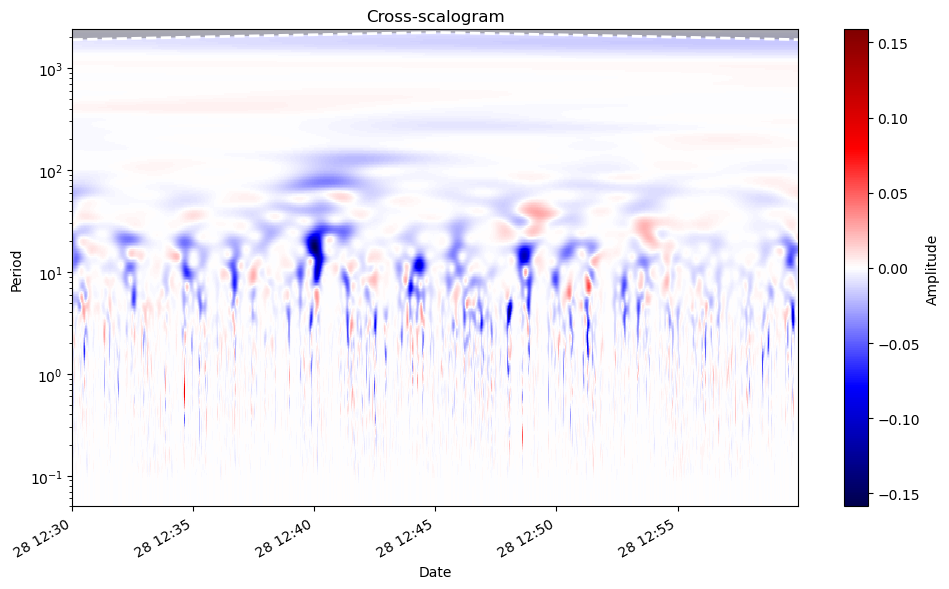

In [5]:
# Perform the wavelet transform on the selected portion of the data
wdata = WT(w_prime, permin=ts, permax=60*40, ts=ts,
                              wname='mor', pad='none',
                              use_pyfftw=True, xdata=time_axis_prime, workers=2)
# Perform the cross wavelet transform between w and c
wdata.xwt(c_prime)

# Compute the covariance and extract its distribution across scales
covrec, covrecscales, _ = wdata.compute_covariance(mask)
display(f"Covariance estimated by CWT: {covrec}")

# Visualize the cross scalogram for the selected 30-minute window
wdata.cross_scalogram(xdata=time_axis_prime,mask=mask,color_norm='max')